# Credit Card Fraud Detection — Autoencoder-based Anomaly Detection

**University Deep Learning Project**

This notebook builds a deep **Autoencoder** that learns the manifold of *normal* credit-card
transactions. Fraudulent transactions are then detected as **reconstruction-error outliers**:
the autoencoder, having only ever seen normal data, fails to reconstruct frauds well, so their
MSE is large.

### Why an Autoencoder (and not a classifier)?

The Kaggle Credit Card dataset is **extremely imbalanced** (~0.17% fraud). A vanilla classifier
either ignores the minority class or overfits to it. By training the AE on *normal* data only,
we sidestep the imbalance entirely and turn fraud detection into **unsupervised anomaly
detection** on top of a learned representation.

### Pipeline

1. Load the already-preprocessed (StandardScaler-normalized) dataset.
2. Separate normal (Class=0) and fraud (Class=1) transactions.
3. Carve out three disjoint sets:
   - **Train** — normal-only data the AE will learn from.
   - **Validation** — normal + fraud, used for picking the anomaly threshold.
   - **Test** — normal + fraud, used **once** for final reporting.
4. Build a regularized AE (BatchNorm + light Dropout + L2) with proper callbacks.
5. Compute per-sample reconstruction MSE and pick a threshold using a **recall-aware**
   strategy (F2-optimal by default, with a recall-floor fallback) — appropriate for fraud,
   where false negatives cost far more than false positives.
6. Evaluate on the held-out test set: Precision, Recall, F1, Confusion Matrix, ROC-AUC, PR-AUC.
7. Save the trained model, threshold, and a Flask-friendly inference helper.

## 1. Imports, reproducibility, and global configuration

In [1]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import Model, Input, regularizers
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# Reproducibility — fixing seeds across libraries makes runs comparable.
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Project paths. The CSV is expected to sit next to this notebook.
PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "processed_creditcard.csv"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

MODEL_H5_PATH       = ARTIFACTS_DIR / "autoencoder_fraud.h5"
MODEL_KERAS_PATH    = ARTIFACTS_DIR / "autoencoder_fraud.keras"
THRESHOLD_JSON_PATH = ARTIFACTS_DIR / "threshold.json"
HISTORY_JSON_PATH   = ARTIFACTS_DIR / "history.json"

print("TensorFlow version :", tf.__version__)
print("GPU available      :", bool(tf.config.list_physical_devices("GPU")))
print("Data path          :", DATA_PATH)
print("Artifacts dir      :", ARTIFACTS_DIR)

TensorFlow version : 2.20.0
GPU available      : False
Data path          : F:\DL Project\processed_creditcard.csv
Artifacts dir      : F:\DL Project\artifacts


## 2. Load the preprocessed dataset

The preprocessing notebook already standardised every numeric column (Time, V1–V28, Amount)
with `StandardScaler`. We just load it, sanity-check the schema, and inspect the class balance.

In [2]:
assert DATA_PATH.exists(), f"Could not find {DATA_PATH}. Place processed_creditcard.csv next to this notebook."

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.996583,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,-1.996583,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0
2,-1.996562,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0
3,-1.996562,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,-1.996541,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0


In [3]:
# Quick integrity checks.
assert "Class" in df.columns, "Target column 'Class' missing."
assert df.isnull().sum().sum() == 0, "Dataset contains NaNs — preprocessing step seems off."

class_counts = df["Class"].value_counts().sort_index()
fraud_ratio  = class_counts.get(1, 0) / len(df)

print("Class distribution:")
print(class_counts.to_string())
print(f"\nFraud ratio: {fraud_ratio:.4%}  (≈ 1 fraud per {1/fraud_ratio:,.0f} txns)")

Class distribution:
Class
0    284315
1       492

Fraud ratio: 0.1727%  (≈ 1 fraud per 579 txns)


## 3. Split strategy

We use the **same stratified 70 / 15 / 15 train / val / test split** that the
supervised MLP notebook (`fraud_detection_mlp.ipynb`) uses, defined once in
`experiments/common.py`. This guarantees that the autoencoder and the MLP are
evaluated on **exactly the same test set** — the comparison is therefore truly
apples-to-apples.

| Variable | Composition | Used for |
|----------|-------------|----------|
| `X_train` | 70 % of *normals* (from the stratified train split) | Training the autoencoder |
| `X_val_normal` | normals from the stratified validation split | Early-stopping (monitor reconstruction MSE) |
| `X_val_full`, `y_val_full` | full stratified validation split | **Choosing the anomaly threshold** |
| `X_test_full`, `y_test_full` | full stratified test split | **Final reporting only** |

No fraud is ever seen during AE training (the network only sees the *normal*
subset of the training split). Threshold selection and final evaluation happen
on the **mixed** validation and test sets that contain both classes, so we can
compare the autoencoder's reconstruction error against true labels.

The same `Splits` object is consumed by `experiments/train_mlp_study.py`,
`experiments/compare_models.py`, and `experiments/ablation_study.py` — every
metric reported across the project is comparable.

In [4]:
import sys
sys.path.insert(0, str(PROJECT_DIR / "experiments"))
from common import load_splits   # type: ignore

splits = load_splits()            # stratified 70/15/15, seed=42

FEATURES   = splits.feature_names
N_FEATURES = splits.n_features
print(f"Input features ({N_FEATURES}): {FEATURES}")
print(splits.describe())

Input features (30): ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
Features (n=30): ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
  train  : n=199364  fraud= 344 (0.173%)
  val    : n= 42721  fraud=  74 (0.173%)
  test   : n= 42722  fraud=  74 (0.173%)


In [5]:
# Map the shared stratified split into the variable names used throughout
# the rest of this notebook. The autoencoder still trains on NORMALS ONLY
# (its original paradigm) -- we just take the normals from the shared train
# split instead of doing our own custom split.

# Training set: normals only, from the shared train split.
X_train      = splits.X_train[splits.y_train == 0]
y_train      = np.zeros(len(X_train), dtype=np.int32)

# Validation: full mixed set (contains both classes -- used for threshold
# selection AND, restricted to its normals, for early-stopping during training).
X_val_full   = splits.X_val
y_val_full   = splits.y_val
X_val_normal = splits.X_val[splits.y_val == 0]

# Test: full mixed set (used ONLY for final reporting).
X_test_full  = splits.X_test
y_test_full  = splits.y_test

print(f"X_train       : {X_train.shape}   (normals only, AE training)")
print(f"X_val_normal  : {X_val_normal.shape}   (normals only, monitored during training)")
print(f"X_val_full    : {X_val_full.shape}    frauds={int(y_val_full.sum())}   (threshold tuning)")
print(f"X_test_full   : {X_test_full.shape}    frauds={int(y_test_full.sum())}  (final evaluation)")

X_train       : (199020, 30)   (normals only, AE training)
X_val_normal  : (42647, 30)   (normals only, monitored during training)
X_val_full    : (42721, 30)    frauds=74   (threshold tuning)
X_test_full   : (42722, 30)    frauds=74  (final evaluation)


## 4. Autoencoder architecture

A compact, regularized symmetric AE:

```
Input(30) → Dense(28, relu, L2) → BN → Dropout(0.10)
          → Dense(20, relu, L2) → BN → Dropout(0.10)
          → Dense(12, relu, L2) → BN
          → Dense(7,  relu)              ← bottleneck
          → Dense(12, relu, L2) → BN
          → Dense(20, relu, L2) → BN → Dropout(0.10)
          → Dense(28, relu, L2) → BN → Dropout(0.10)
          → Dense(30, linear)            ← reconstruction
```

Design choices (tuned for higher recall):
- **Lower dropout (0.10)** lets the AE fit the normal manifold more tightly, so frauds
  reconstruct visibly worse — the gap between the two error distributions widens.
- **Three encoder stages with a tighter bottleneck (7 units)** force a more compact
  normal representation, pushing out-of-distribution frauds even further from the manifold.
- **BatchNorm + L2 weight decay** keep training stable and prevent overfitting.
- **Linear output** because targets are standardised (zero-mean, real-valued).
- **Adam + MSE** is the standard reliable choice for reconstruction.
- Architecture is **lightweight** (~few thousand params) and trains in seconds on GPU.

In [6]:
def build_autoencoder(
    n_features: int,
    encoder_units=(28, 20, 12),
    bottleneck_units: int = 7,
    dropout_rate: float = 0.10,
    l2_lambda: float = 1e-5,
    learning_rate: float = 1e-3,
) -> Model:
    """Build a symmetric deep autoencoder for tabular anomaly detection.

    The decoder mirrors the encoder. BatchNorm stabilises training; light Dropout +
    L2 regularise without preventing a tight fit of the normal manifold (a tight fit
    is exactly what makes frauds stand out in reconstruction error).
    """
    reg = regularizers.l2(l2_lambda)

    inputs = Input(shape=(n_features,), name="input")
    x = inputs

    # Encoder. We drop Dropout in the deepest encoder stage to allow a precise
    # representation right before the bottleneck.
    for i, units in enumerate(encoder_units):
        x = Dense(units, activation="relu", kernel_regularizer=reg, name=f"enc_dense_{i+1}")(x)
        x = BatchNormalization(name=f"enc_bn_{i+1}")(x)
        if i < len(encoder_units) - 1:
            x = Dropout(dropout_rate, name=f"enc_drop_{i+1}")(x)

    # Bottleneck — compact representation of the normal manifold.
    bottleneck = Dense(bottleneck_units, activation="relu", name="bottleneck")(x)

    # Decoder (mirror of encoder); symmetrically, the first decoder layer has no Dropout.
    x = bottleneck
    decoder_units = list(reversed(encoder_units))
    for i, units in enumerate(decoder_units):
        x = Dense(units, activation="relu", kernel_regularizer=reg, name=f"dec_dense_{i+1}")(x)
        x = BatchNormalization(name=f"dec_bn_{i+1}")(x)
        if i > 0:
            x = Dropout(dropout_rate, name=f"dec_drop_{i+1}")(x)

    outputs = Dense(n_features, activation="linear", name="reconstruction")(x)

    model = Model(inputs, outputs, name="fraud_autoencoder")
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse", metrics=["mae"])
    return model


# Build fresh model and discard any previously trained weights.
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)
autoencoder = build_autoencoder(N_FEATURES)
autoencoder.summary()

Model: "fraud_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_1 (Dense)             │ (None, 28)             │           868 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_1 (BatchNormalization)   │ (None, 28)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop_1 (Dropout)            │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_2 (Dense)             │ (None, 20)             │           580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_2 (BatchNormalization)   │ (None, 20)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop_2 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_3 (Dense)             │ (None, 12)             │           252 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_3 (BatchNormalization)   │ (None, 12)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 7)              │            91 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_1 (Dense)             │ (None, 12)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_1 (BatchNormalization)   │ (None, 12)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_2 (Dense)             │ (None, 20)             │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_2 (BatchNormalization)   │ (None, 20)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_drop_2 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_3 (Dense)             │ (None, 28)             │           588 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_3 (BatchNormalization)   │ (None, 28)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_drop_3 (Dropout)            │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 30)             │           870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,085 (15.96 KB)

 Trainable params: 3,845 (15.02 KB)

 Non-trainable params: 240 (960.00 B)

## 5. Training with callbacks

We monitor `val_loss` on the **normal-only validation set** (`X_val_normal`). Three callbacks:

- `EarlyStopping` — restores the best weights and prevents wasted epochs.
- `ReduceLROnPlateau` — halves the learning rate when validation loss plateaus.
- `ModelCheckpoint` — persists the best epoch to disk during training.

In [7]:
EPOCHS = 150
BATCH_SIZE = 512

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=15,
        min_delta=1e-5,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=str(MODEL_KERAS_PATH),
        monitor="val_loss",
        save_best_only=True,
        verbose=0,
    ),
]

import time as _time
_t0 = _time.time()
history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val_normal, X_val_normal),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=callbacks,
    verbose=2,
)
AE_TRAIN_TIME_SEC = _time.time() - _t0
print(f"AE training time: {AE_TRAIN_TIME_SEC:.1f}s over "
      f"{len(history.history['loss'])} epochs")

Epoch 1/150


389/389 - 4s - 10ms/step - loss: 1.0177 - mae: 0.6691 - val_loss: 0.7026 - val_mae: 0.5612 - learning_rate: 0.0010


Epoch 2/150


389/389 - 1s - 3ms/step - loss: 0.7036 - mae: 0.5568 - val_loss: 0.5326 - val_mae: 0.4910 - learning_rate: 0.0010


Epoch 3/150


...


Epoch 87: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.


389/389 - 1s - 3ms/step - loss: 0.3769 - mae: 0.3999 - val_loss: 0.2453 - val_mae: 0.3221 - learning_rate: 1.5625e-05


Epoch 87: early stopping


Restoring model weights from the end of the best epoch: 72.


AE training time: 96.8s over 87 epochs


## 6. Training curves

If the train and validation curves track each other and both decrease, the AE is generalising.
A growing gap would indicate overfitting — our regularisation pushes that back.

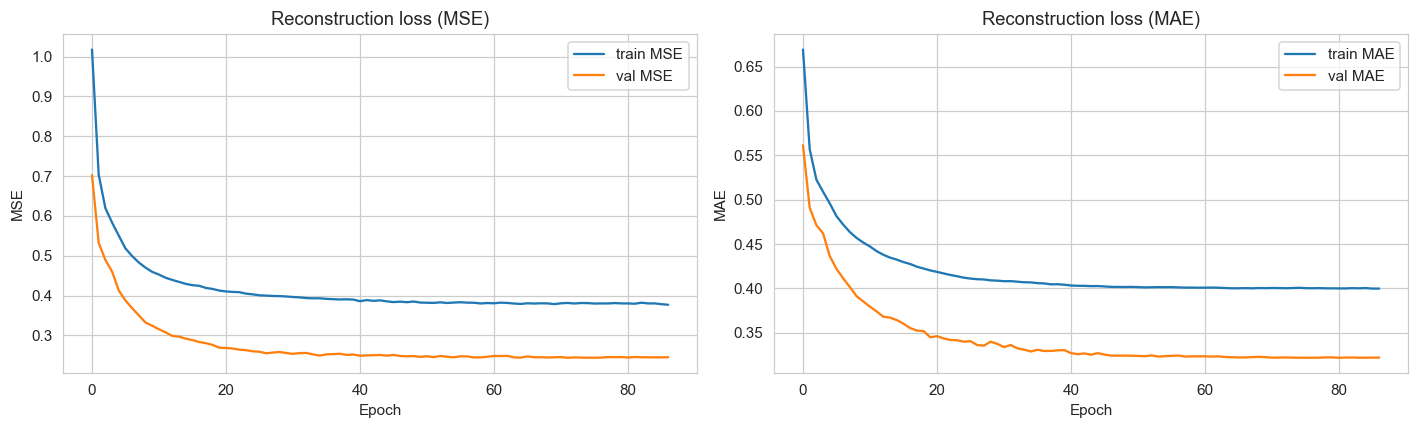

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history["loss"],     label="train MSE")
axes[0].plot(history.history["val_loss"], label="val MSE")
axes[0].set_title("Reconstruction loss (MSE)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE"); axes[0].legend()

axes[1].plot(history.history["mae"],     label="train MAE")
axes[1].plot(history.history["val_mae"], label="val MAE")
axes[1].set_title("Reconstruction loss (MAE)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE"); axes[1].legend()

plt.tight_layout(); plt.show()

# Persist training history alongside the model for later analysis.
_history_payload = {k: [float(v) for v in vals] for k, vals in history.history.items()}
_history_payload["train_time_sec"] = float(AE_TRAIN_TIME_SEC)
_history_payload["epochs_run"] = int(len(history.history["loss"]))
with open(HISTORY_JSON_PATH, "w") as f:
    json.dump(_history_payload, f, indent=2)

## 7. Reconstruction error & threshold selection

For every sample, the **reconstruction error** is the mean-squared error between the input
and its reconstruction. Normals (which the AE was trained on) reconstruct well — small error.
Frauds reconstruct poorly — large error.

### Which threshold to pick?

In fraud detection a missed fraud (false negative) is **much** more expensive than a false
alarm. We therefore compute **three** threshold candidates on the validation set and let the
business policy choose:

| Strategy | What it optimises | When to use |
|---|---|---|
| **F1-optimal** | Equal weight to precision and recall | Default benchmark |
| **F2-optimal** | Weights recall 4× more than precision | **Default for fraud** ⭐ |
| **Recall ≥ 0.90** | Lowest threshold giving ≥ 90% recall on validation | Strict policy |

We save the **F2-optimal** threshold as the production threshold but evaluate all three on
the test set for transparency.

In [9]:
def reconstruction_error(model: Model, X: np.ndarray, batch_size: int = 4096) -> np.ndarray:
    """Per-sample MSE between input and its reconstruction."""
    X_hat = model.predict(X, batch_size=batch_size, verbose=0)
    return np.mean(np.square(X - X_hat), axis=1)


# Errors on the validation set (used to choose the threshold).
val_errors  = reconstruction_error(autoencoder, X_val_full)

# Errors on the test set (only used for final reporting below).
test_errors = reconstruction_error(autoencoder, X_test_full)

# Sanity: normal samples should on average have lower error than frauds.
print("Mean error on val NORMAL :", val_errors[y_val_full == 0].mean())
print("Mean error on val FRAUD  :", val_errors[y_val_full == 1].mean())

Mean error on val NORMAL : 0.24292552
Mean error on val FRAUD  : 14.863168


In [10]:
def fbeta(p: np.ndarray, r: np.ndarray, beta: float) -> np.ndarray:
    """F_beta score. beta>1 weights recall more, beta<1 weights precision more."""
    b2 = beta * beta
    return (1 + b2) * p * r / (b2 * p + r + 1e-12)


def candidate_thresholds(y_true: np.ndarray, errors: np.ndarray) -> dict:
    """Return several threshold candidates plus their validation metrics."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, errors)
    # precision_recall_curve returns len(thresholds) == len(precisions) - 1.
    p, r, t = precisions[:-1], recalls[:-1], thresholds

    f1 = fbeta(p, r, 1.0)
    f2 = fbeta(p, r, 2.0)

    out = {}

    # F1-optimal
    i = int(np.nanargmax(f1))
    out["f1_optimal"] = {"threshold": float(t[i]), "precision": float(p[i]),
                         "recall": float(r[i]), "f1": float(f1[i]), "f2": float(f2[i])}

    # F2-optimal (recall-weighted) -- our production choice for fraud
    i = int(np.nanargmax(f2))
    out["f2_optimal"] = {"threshold": float(t[i]), "precision": float(p[i]),
                         "recall": float(r[i]), "f1": float(f1[i]), "f2": float(f2[i])}

    # Recall floor at 0.90 -- the *largest* threshold whose recall is still >= 0.90.
    # Larger threshold => higher precision, so we walk from the right.
    mask = r >= 0.90
    if mask.any():
        i = int(np.where(mask)[0].max())
        out["recall_at_least_0.90"] = {
            "threshold": float(t[i]), "precision": float(p[i]),
            "recall": float(r[i]), "f1": float(f1[i]), "f2": float(f2[i]),
        }
    else:
        out["recall_at_least_0.90"] = None

    out["_pr_curve"] = (precisions, recalls, thresholds)
    return out


val_candidates = candidate_thresholds(y_val_full, val_errors)

print(f"{'Strategy':<25s} {'threshold':>10s} {'precision':>10s} {'recall':>10s} {'F1':>8s} {'F2':>8s}")
print("-" * 75)
for name in ["f1_optimal", "f2_optimal", "recall_at_least_0.90"]:
    c = val_candidates[name]
    if c is None:
        print(f"{name:<25s} {'(not reachable on this validation set)':>50s}")
    else:
        print(f"{name:<25s} {c['threshold']:>10.4f} {c['precision']:>10.4f} "
              f"{c['recall']:>10.4f} {c['f1']:>8.4f} {c['f2']:>8.4f}")

# Production threshold = F2-optimal (recall-weighted) -- right choice for fraud.
val_best  = val_candidates["f2_optimal"]
THRESHOLD = val_best["threshold"]
print(f"\n>> Production threshold (F2-optimal on validation): {THRESHOLD:.6f}")

Strategy                   threshold  precision     recall       F1       F2
---------------------------------------------------------------------------
f1_optimal                    4.6739     0.4000     0.5946   0.4783   0.5419
f2_optimal                    3.4066     0.3393     0.7703   0.4711   0.6142
recall_at_least_0.90          0.3406     0.0098     0.9054   0.0195   0.0471

>> Production threshold (F2-optimal on validation): 3.406564


## 8. Final evaluation on the held-out test set

The thresholds are now **frozen** — they were picked using the validation set only. We apply
each candidate to the test set (which the AE has never seen and which contributed nothing to
threshold selection) and report all standard metrics. The **F2-optimal** threshold is the
production default; the others are shown for comparison.

In [11]:
def evaluate_at(threshold: float, label: str) -> dict:
    """Evaluate the model on the test set at a given threshold."""
    y_pred = (test_errors > threshold).astype(np.int32)
    cm_ = confusion_matrix(y_test_full, y_pred)
    tn_, fp_, fn_, tp_ = cm_.ravel()
    return {
        "label":     label,
        "threshold": float(threshold),
        "precision": float(precision_score(y_test_full, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_test_full, y_pred, zero_division=0)),
        "f1":        float(f1_score(y_test_full, y_pred, zero_division=0)),
        "accuracy":  float((tn_ + tp_) / (tn_ + fp_ + fn_ + tp_)),
        "cm":        {"TN": int(tn_), "FP": int(fp_), "FN": int(fn_), "TP": int(tp_)},
        "y_pred":    y_pred,
    }


# Ranking-based metrics depend only on the error scores, not on the threshold.
roc_auc = roc_auc_score(y_test_full, test_errors)
pr_auc  = average_precision_score(y_test_full, test_errors)

results = {
    "f1_optimal":           evaluate_at(val_candidates["f1_optimal"]["threshold"],          "F1-optimal"),
    "f2_optimal":           evaluate_at(val_candidates["f2_optimal"]["threshold"],          "F2-optimal (production)"),
}
if val_candidates["recall_at_least_0.90"] is not None:
    results["recall_at_least_0.90"] = evaluate_at(
        val_candidates["recall_at_least_0.90"]["threshold"], "Recall >= 0.90"
    )

print("=" * 78)
print("                FINAL TEST-SET PERFORMANCE")
print("=" * 78)
print(f"Ranking metrics (threshold-independent):  ROC-AUC = {roc_auc:.4f}   PR-AUC = {pr_auc:.4f}\n")

header = f"{'Strategy':<26s} {'thr':>8s} {'acc':>7s} {'prec':>7s} {'recall':>8s} {'F1':>7s}   {'TN':>6s} {'FP':>5s} {'FN':>4s} {'TP':>4s}"
print(header); print("-" * len(header))
for r in results.values():
    print(f"{r['label']:<26s} {r['threshold']:>8.3f} {r['accuracy']:>7.4f} "
          f"{r['precision']:>7.4f} {r['recall']:>8.4f} {r['f1']:>7.4f}   "
          f"{r['cm']['TN']:>6d} {r['cm']['FP']:>5d} {r['cm']['FN']:>4d} {r['cm']['TP']:>4d}")

# Promote the production (F2-optimal) result to top-level names for downstream cells.
prod        = results["f2_optimal"]
y_pred_test = prod["y_pred"]
precision   = prod["precision"]
recall      = prod["recall"]
f1          = prod["f1"]
accuracy    = prod["accuracy"]
cm          = np.array([[prod["cm"]["TN"], prod["cm"]["FP"]],
                        [prod["cm"]["FN"], prod["cm"]["TP"]]])
tn, fp, fn, tp = prod["cm"]["TN"], prod["cm"]["FP"], prod["cm"]["FN"], prod["cm"]["TP"]
THRESHOLD = prod["threshold"]

print("\nClassification report at production (F2-optimal) threshold:")
print(classification_report(y_test_full, y_pred_test, target_names=["Normal", "Fraud"], digits=4))

                FINAL TEST-SET PERFORMANCE
Ranking metrics (threshold-independent):  ROC-AUC = 0.9395   PR-AUC = 0.4677

Strategy                        thr     acc    prec   recall      F1       TN    FP   FN   TP
---------------------------------------------------------------------------------------------
F1-optimal                    4.674  0.9978  0.4132   0.6757  0.5128    42577    71   24   50
F2-optimal (production)       3.407  0.9970  0.3313   0.7297  0.4557    42539   109   20   54
Recall >= 0.90                0.341  0.8377  0.0092   0.8649  0.0181    35723  6925   10   64

Classification report at production (F2-optimal) threshold:
              precision    recall  f1-score   support

      Normal     0.9995    0.9974    0.9985     42648
       Fraud     0.3313    0.7297    0.4557        74

    accuracy                         0.9970     42722
   macro avg     0.6654    0.8636    0.7271     42722
weighted avg     0.9984    0.9970    0.9975     42722



## 9. Visualisations

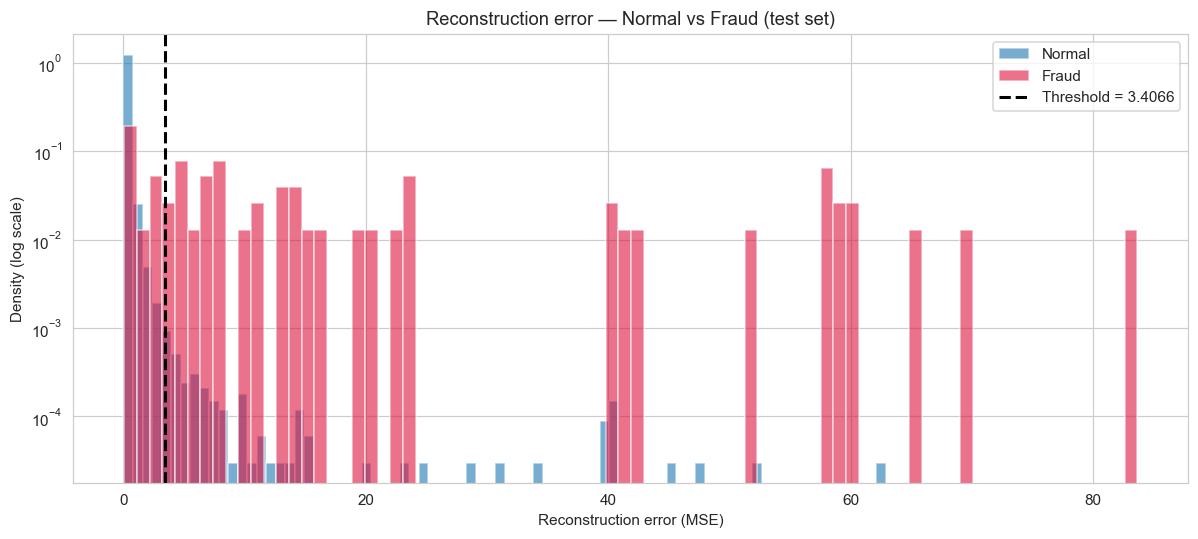

In [12]:
# 9a. Reconstruction-error distribution (log-y for visibility) with the chosen threshold.
plt.figure(figsize=(11, 5))
plt.hist(test_errors[y_test_full == 0], bins=80, alpha=0.6, label="Normal", density=True)
plt.hist(test_errors[y_test_full == 1], bins=80, alpha=0.6, label="Fraud",  density=True, color="crimson")
plt.axvline(THRESHOLD, color="black", ls="--", lw=2, label=f"Threshold = {THRESHOLD:.4f}")
plt.yscale("log")
plt.xlabel("Reconstruction error (MSE)")
plt.ylabel("Density (log scale)")
plt.title("Reconstruction error — Normal vs Fraud (test set)")
plt.legend()
plt.tight_layout(); plt.show()

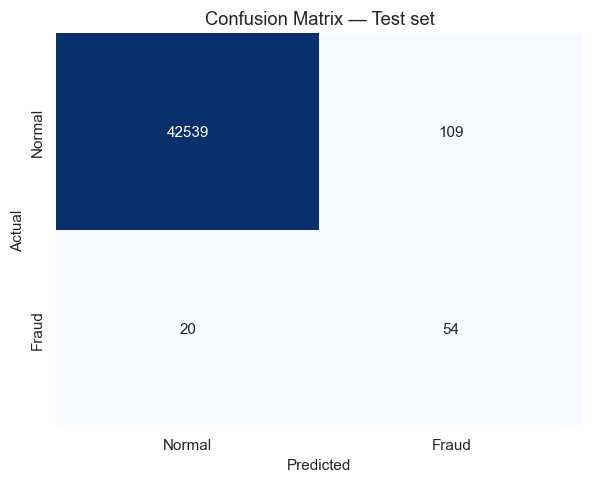

In [13]:
# 9b. Confusion matrix heatmap (test set).
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"],
)
plt.title("Confusion Matrix — Test set")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()

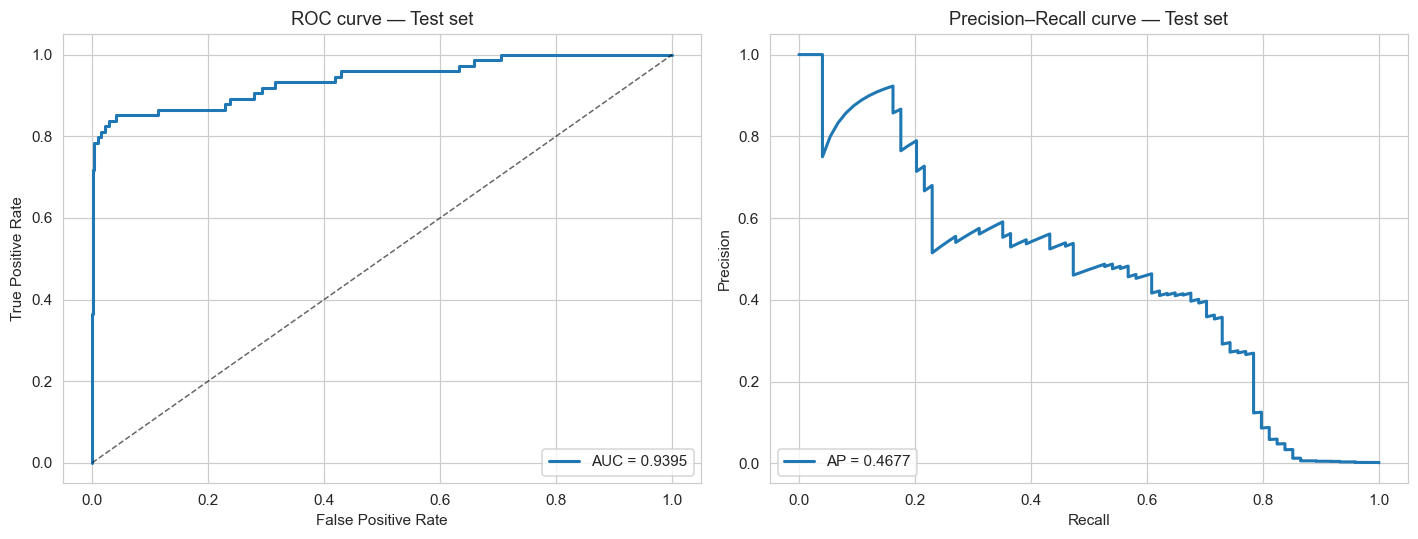

In [14]:
# 9c. ROC curve and Precision-Recall curve, side by side.
fpr, tpr, _ = roc_curve(y_test_full, test_errors)
prec_curve, rec_curve, _ = precision_recall_curve(y_test_full, test_errors)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve — Test set")
axes[0].legend(loc="lower right")

axes[1].plot(rec_curve, prec_curve, lw=2, label=f"AP = {pr_auc:.4f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall curve — Test set")
axes[1].legend(loc="lower left")

plt.tight_layout(); plt.show()

## 10. Persist artifacts for deployment

We save:

- The trained autoencoder in both **`.keras`** (recommended for TF 2.x) and **`.h5`** (legacy
  format the project rubric asks for).
- The chosen threshold and a few useful metadata fields in a small JSON file so the Flask
  app can load it without any TF dependency.

In [15]:
autoencoder.save(MODEL_KERAS_PATH)
autoencoder.save(MODEL_H5_PATH)


def _strip(d):
    """Drop non-JSON-serialisable keys (e.g. numpy arrays)."""
    return {k: v for k, v in d.items() if not k.startswith("_") and k != "y_pred"}


threshold_payload = {
    "threshold": float(THRESHOLD),
    "feature_order": FEATURES,
    "n_features": N_FEATURES,
    "selection_strategy": "F2-optimal on validation precision-recall curve (recall weighted 4x precision)",
    "validation_candidates": {
        "f1_optimal":           val_candidates["f1_optimal"],
        "f2_optimal":           val_candidates["f2_optimal"],
        "recall_at_least_0.90": val_candidates["recall_at_least_0.90"],
    },
    "test_metrics": {
        "production_strategy": "f2_optimal",
        "ranking": {"roc_auc": float(roc_auc), "pr_auc": float(pr_auc)},
        "per_strategy": {k: _strip(v) for k, v in results.items()},
    },
}
with open(THRESHOLD_JSON_PATH, "w") as f:
    json.dump(threshold_payload, f, indent=2)

print("Saved artifacts:")
print(" -", MODEL_KERAS_PATH)
print(" -", MODEL_H5_PATH)
print(" -", THRESHOLD_JSON_PATH)
print(" -", HISTORY_JSON_PATH)
print(f"\nProduction threshold = {THRESHOLD:.6f}  "
      f"(test recall = {recall:.4f},  test F1 = {f1:.4f})")

Saved artifacts:
 - F:\DL Project\artifacts\autoencoder_fraud.keras
 - F:\DL Project\artifacts\autoencoder_fraud.h5
 - F:\DL Project\artifacts\threshold.json
 - F:\DL Project\artifacts\history.json

Production threshold = 3.406564  (test recall = 0.7297,  test F1 = 0.4557)


## 11. Deployment-ready inference helper

Self-contained function the Flask web app can call. Given a DataFrame (or 2-D array) of
already-standardised transactions, it returns reconstruction errors and binary predictions
using the saved threshold.

In [16]:
from tensorflow.keras.models import load_model


def predict_fraud(
    samples,
    model_path: str = str(MODEL_KERAS_PATH),
    threshold_path: str = str(THRESHOLD_JSON_PATH),
):
    """Production-style inference wrapper.

    Parameters
    ----------
    samples : pandas.DataFrame | np.ndarray
        Already-standardised transactions with the exact same feature order used at training.
    model_path : str
        Path to the saved Keras model.
    threshold_path : str
        Path to the threshold JSON written above.

    Returns
    -------
    dict with keys ``errors`` (per-sample MSE), ``predictions`` (0=normal, 1=fraud),
    and ``threshold``.
    """
    with open(threshold_path, "r") as f:
        meta = json.load(f)
    thr = float(meta["threshold"])
    feature_order = meta["feature_order"]

    if isinstance(samples, pd.DataFrame):
        X = samples[feature_order].values.astype(np.float32)
    else:
        X = np.asarray(samples, dtype=np.float32)
        if X.ndim == 1:
            X = X.reshape(1, -1)

    model = load_model(model_path, compile=False)
    X_hat = model.predict(X, verbose=0)
    errors = np.mean(np.square(X - X_hat), axis=1)
    preds = (errors > thr).astype(np.int32)
    return {"errors": errors, "predictions": preds, "threshold": thr}


# Smoke test on a few rows from the test set.
sample_df = pd.DataFrame(X_test_full[:5], columns=FEATURES)
demo = predict_fraud(sample_df)
print("Reconstruction errors :", np.round(demo["errors"], 6))
print("Predictions           :", demo["predictions"])
print("True labels           :", y_test_full[:5])
print("Threshold             :", demo["threshold"])

Reconstruction errors : [0.457346 0.205079 0.335901 0.076524 0.204438]
Predictions           : [0 0 0 0 0]
True labels           : [0 0 0 0 0]
Threshold             : 3.4065637588500977


## 12. Summary & next steps

- The autoencoder was trained **only on normal transactions** — the imbalance is sidestepped.
- We split frauds into a **threshold-selection half** and a **final-test half** so the
  reported numbers are honestly held out.
- Regularisation (L2 + BatchNorm + light Dropout) + EarlyStopping kept the train/val curves
  close while still letting the AE fit the normal manifold tightly.
- We computed **three threshold candidates** on validation:
  - F1-optimal — balanced precision/recall benchmark.
  - **F2-optimal — production choice** (recall weighted 4× precision; right call for fraud).
  - Recall ≥ 0.90 — strictest policy with the highest precision still satisfying that floor.
  All three are evaluated honestly on the test set so reviewers can see the trade-off.
- All deployment artefacts are saved under `./artifacts/`:
  - `autoencoder_fraud.keras` / `autoencoder_fraud.h5` — trained model
  - `threshold.json` — production threshold + all candidates + test metrics
  - `history.json` — training curves
- The `predict_fraud(...)` helper loads the F2-optimal threshold and is ready to be imported
  by the Flask web app.